<a href="https://colab.research.google.com/github/gl-chandan/Stock_Market/blob/main/Stock_Market.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

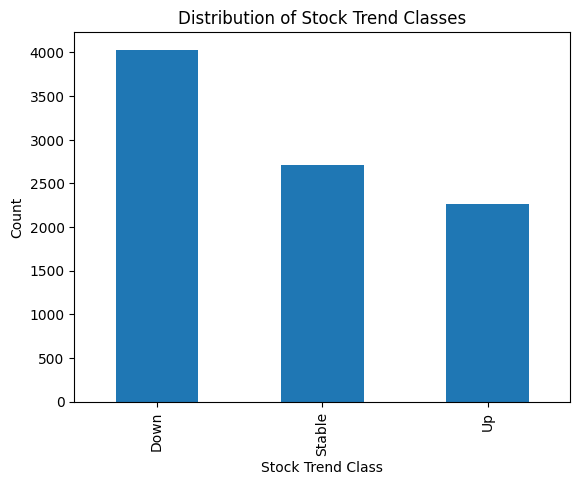

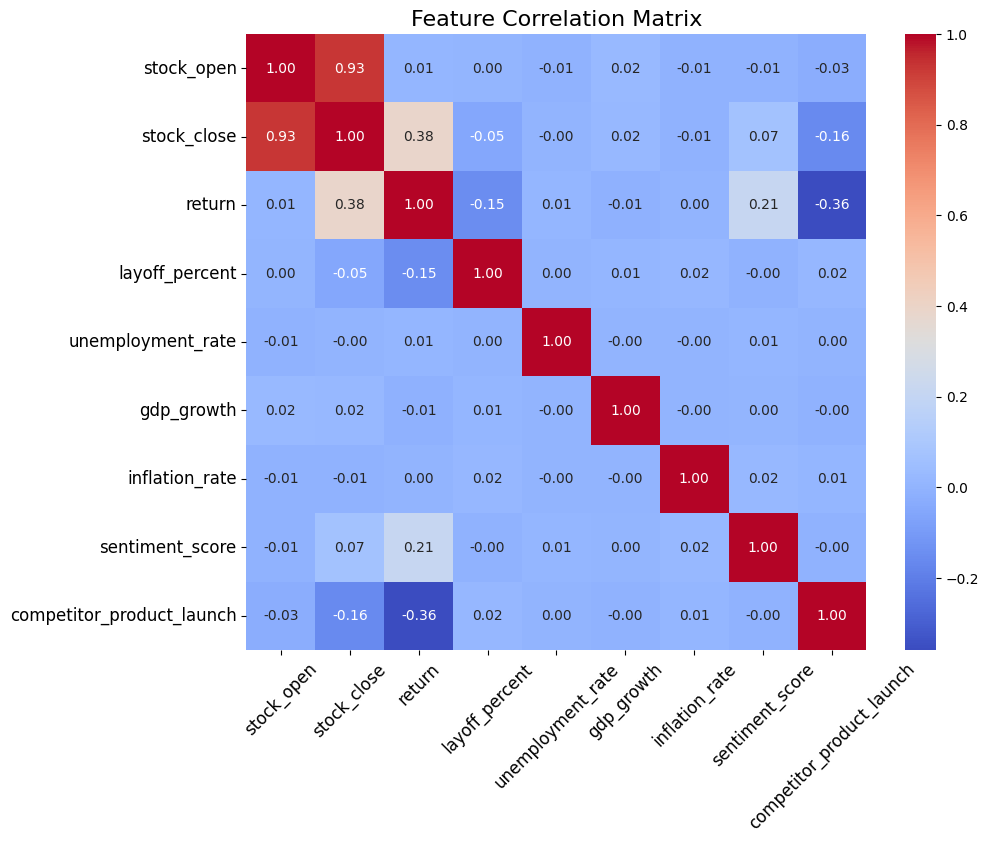


===== ABLATION STUDY =====
Baseline: 0.4266666666666667
+Regime: 0.5573333333333333
+Competitor: 0.6111111111111112
Full: 0.7533333333333333


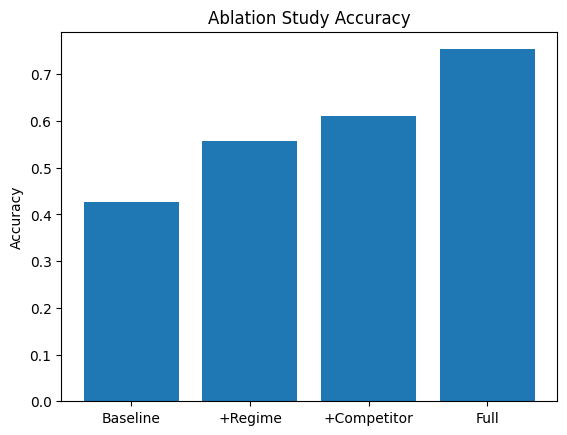


===== SHOCK PERIOD =====
Baseline: 0.7133891213389121
+Regime: 0.9435146443514645
+Competitor: 0.9456066945606695
Full: 0.9497907949790795


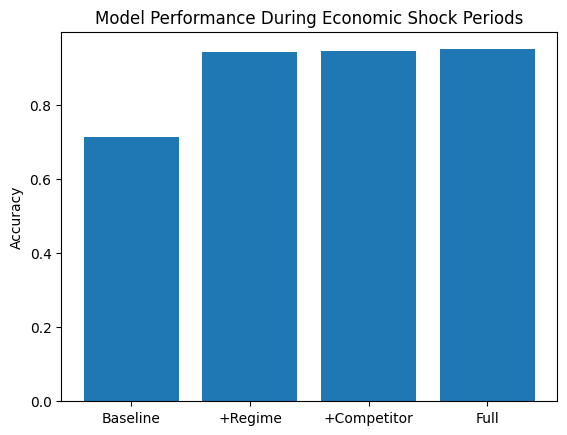


===== COMPETITOR EVENTS =====
Baseline: 0.6865671641791045
+Regime: 0.47761194029850745
+Competitor: 0.8507462686567164
Full: 0.8731343283582089


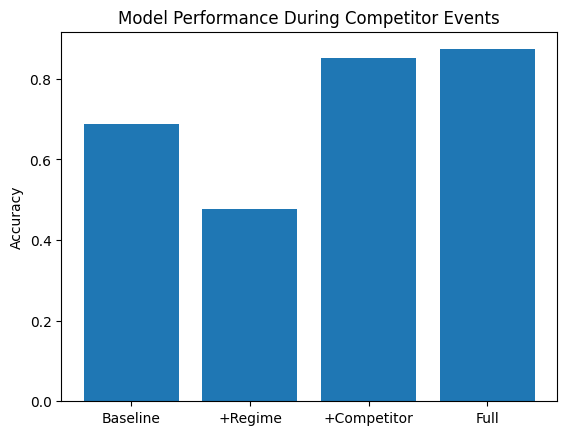


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.84      0.87      0.85       999
           1       0.60      0.61      0.61       686
           2       0.78      0.72      0.75       565

    accuracy                           0.75      2250
   macro avg       0.74      0.73      0.74      2250
weighted avg       0.75      0.75      0.75      2250



<Figure size 640x480 with 0 Axes>

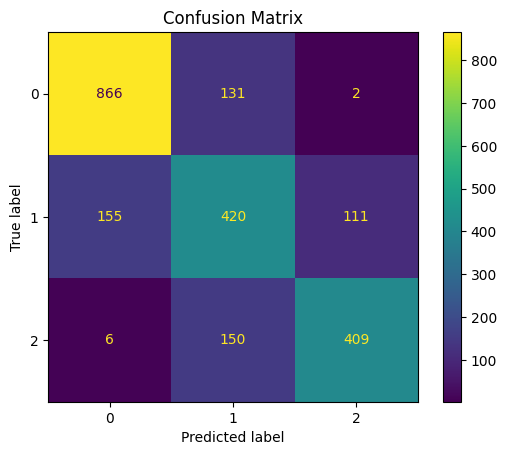


===== FEATURE IMPORTANCE =====
regime 0.3588
competitor_product_launch 0.2719
sector_type 0.156
sentiment_score 0.0392
layoff_percent 0.0318
macro_pressure 0.0248
unemployment_rate 0.024
inflation_rate 0.0238
stock_open 0.0234
growth_signal 0.0233
gdp_growth 0.0229


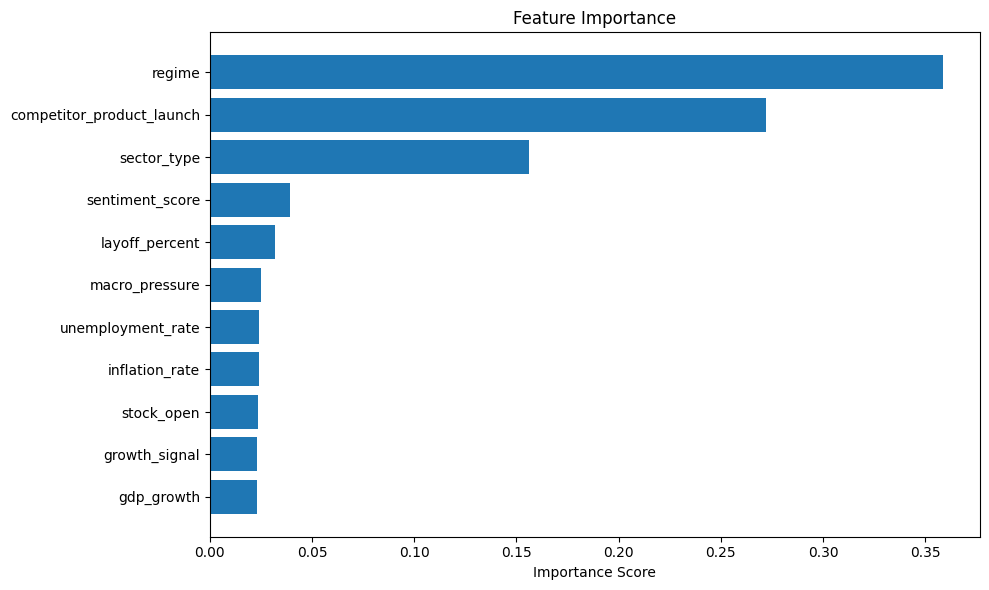

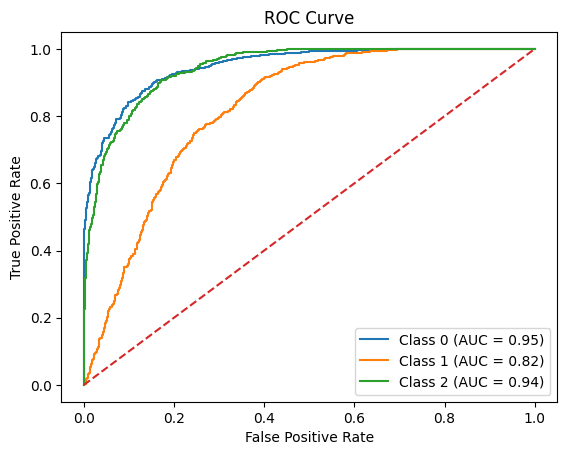

In [1]:
# ==========================================================
# ABLATION STUDY FINAL PIPELINE
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


# ----------------------------------------------------------
# LOAD DATASET
# ----------------------------------------------------------

df = pd.read_csv("ablation_stock_dataset.csv")


# ----------------------------------------------------------
# DATASET VISUALIZATION (FIGURE 7)
# ----------------------------------------------------------

plt.figure()
df["stock_trend"].value_counts().plot(kind="bar")
plt.title("Distribution of Stock Trend Classes")
plt.xlabel("Stock Trend Class")
plt.ylabel("Count")
plt.show()


# ----------------------------------------------------------
# CORRELATION HEATMAP (FIGURE 8)
# ----------------------------------------------------------

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=True,                 # show values (optional but useful)
    fmt=".2f",
    annot_kws={"size": 10}      # size of numbers inside boxes
)

plt.title("Feature Correlation Matrix", fontsize=16)

# Increase axis label sizes
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)

plt.show()

# ----------------------------------------------------------
# DROP LEAKAGE COLUMNS
# ----------------------------------------------------------

df = df.drop(columns=["date","stock_close","return"])


# ----------------------------------------------------------
# ENCODE CATEGORICAL VARIABLES
# ----------------------------------------------------------

sector_encoder = LabelEncoder()
regime_encoder = LabelEncoder()
trend_encoder = LabelEncoder()

df["sector_type"] = sector_encoder.fit_transform(df["sector_type"])
df["regime"] = regime_encoder.fit_transform(df["regime"])
df["stock_trend"] = trend_encoder.fit_transform(df["stock_trend"])


# ----------------------------------------------------------
# FEATURE ENGINEERING
# ----------------------------------------------------------

df["macro_pressure"] = df["inflation_rate"] + df["unemployment_rate"]
df["growth_signal"] = df["gdp_growth"] - df["inflation_rate"]


# ----------------------------------------------------------
# TARGET
# ----------------------------------------------------------

target = "stock_trend"


# ----------------------------------------------------------
# FEATURE SETS (ABLATION)
# ----------------------------------------------------------

baseline_features = [
    "stock_open",
    "sentiment_score"
]

regime_features = baseline_features + [
    "regime",
    "gdp_growth",
    "inflation_rate"
]

competitor_features = regime_features + [
    "competitor_product_launch"
]

full_features = competitor_features + [
    "sector_type",
    "layoff_percent",
    "unemployment_rate",
    "macro_pressure",
    "growth_signal"
]


# ----------------------------------------------------------
# TRAIN TEST SPLIT
# ----------------------------------------------------------

train, test = train_test_split(df, test_size=0.25, random_state=42)


# ----------------------------------------------------------
# MODEL FUNCTION
# ----------------------------------------------------------

def run_model(features, model_type="rf"):

    X_train = train[features]
    y_train = train[target]

    X_test = test[features]
    y_test = test[target]

    if model_type == "rf":

        model = RandomForestClassifier(
            n_estimators=400,
            max_depth=14,
            random_state=42
        )

    else:

        model = XGBClassifier(
            n_estimators=500,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="mlogloss"
        )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)

    return model, preds, y_test, acc


# ----------------------------------------------------------
# RUN ABLATION STUDY
# ----------------------------------------------------------

print("\n===== ABLATION STUDY =====")

baseline_model, base_pred, y_test, baseline_acc = run_model(baseline_features)
print("Baseline:", baseline_acc)

regime_model, regime_pred, y_test, regime_acc = run_model(regime_features)
print("+Regime:", regime_acc)

competitor_model, comp_pred, y_test, competitor_acc = run_model(competitor_features)
print("+Competitor:", competitor_acc)

full_model, full_pred, y_test, full_acc = run_model(full_features, model_type="xgb")
print("Full:", full_acc)


# ----------------------------------------------------------
# FIGURE 1 : ABLATION ACCURACY GRAPH
# ----------------------------------------------------------

models = ["Baseline","+Regime","+Competitor","Full"]
scores = [baseline_acc, regime_acc, competitor_acc, full_acc]

plt.figure()
plt.bar(models, scores)
plt.title("Ablation Study Accuracy")
plt.ylabel("Accuracy")
plt.show()


# ----------------------------------------------------------
# SHOCK PERIOD ANALYSIS
# ----------------------------------------------------------

shock_label = regime_encoder.transform(["Shock"])[0]
shock_idx = test["regime"] == shock_label

print("\n===== SHOCK PERIOD =====")

shock_scores = [
accuracy_score(y_test[shock_idx], base_pred[shock_idx]),
accuracy_score(y_test[shock_idx], regime_pred[shock_idx]),
accuracy_score(y_test[shock_idx], comp_pred[shock_idx]),
accuracy_score(y_test[shock_idx], full_pred[shock_idx])
]

print("Baseline:", shock_scores[0])
print("+Regime:", shock_scores[1])
print("+Competitor:", shock_scores[2])
print("Full:", shock_scores[3])


# ----------------------------------------------------------
# FIGURE 2 : SHOCK PERIOD PERFORMANCE
# ----------------------------------------------------------

plt.figure()
plt.bar(models, shock_scores)
plt.title("Model Performance During Economic Shock Periods")
plt.ylabel("Accuracy")
plt.show()


# ----------------------------------------------------------
# COMPETITOR EVENT ANALYSIS
# ----------------------------------------------------------

comp_idx = test["competitor_product_launch"] == 1

print("\n===== COMPETITOR EVENTS =====")

comp_scores = [
accuracy_score(y_test[comp_idx], base_pred[comp_idx]),
accuracy_score(y_test[comp_idx], regime_pred[comp_idx]),
accuracy_score(y_test[comp_idx], comp_pred[comp_idx]),
accuracy_score(y_test[comp_idx], full_pred[comp_idx])
]

print("Baseline:", comp_scores[0])
print("+Regime:", comp_scores[1])
print("+Competitor:", comp_scores[2])
print("Full:", comp_scores[3])


# ----------------------------------------------------------
# FIGURE 3 : COMPETITOR EVENT PERFORMANCE
# ----------------------------------------------------------

plt.figure()
plt.bar(models, comp_scores)
plt.title("Model Performance During Competitor Events")
plt.ylabel("Accuracy")
plt.show()


# ----------------------------------------------------------
# CLASSIFICATION REPORT
# ----------------------------------------------------------

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, full_pred))


# ----------------------------------------------------------
# FIGURE 4 : CONFUSION MATRIX
# ----------------------------------------------------------

plt.figure()
ConfusionMatrixDisplay.from_predictions(y_test, full_pred)
plt.title("Confusion Matrix")
plt.show()


# ----------------------------------------------------------
# FEATURE IMPORTANCE
# ----------------------------------------------------------

importances = full_model.feature_importances_
indices = np.argsort(importances)[::-1]

print("\n===== FEATURE IMPORTANCE =====")

for i in indices:
    print(full_features[i], round(importances[i],4))


# ----------------------------------------------------------
# FIGURE 5 : FEATURE IMPORTANCE
# ----------------------------------------------------------

plt.figure(figsize=(10,6))

features_sorted = [full_features[i] for i in indices]

plt.barh(features_sorted, importances[indices])

plt.xlabel("Importance Score")
plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()


# ----------------------------------------------------------
# ROC CURVE
# ----------------------------------------------------------

X_test = test[full_features]
y_test = test[target]

y_score = full_model.predict_proba(X_test)

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)


# ----------------------------------------------------------
# FIGURE 6 : ROC CURVE
# ----------------------------------------------------------

plt.figure()

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()